# 04. 데이터 증강 실험

`train_eda_fixed.csv`만 사용한다. 데이터 증강은 train split에만 적용하고, 모델 선택과 confusion matrix는 validation 기준으로만 확인한다.

In [11]:
from pathlib import Path
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# 노트북 출력에서 반복 경고는 숨기고, 그래프 스타일은 공통으로 맞춘다.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


def setup_korean_font():
    def apply_font(font_name, source):
        plt.rcParams['font.family'] = [font_name]
        plt.rcParams['axes.unicode_minus'] = False
        sns.set_theme(style='whitegrid', rc={
            'font.family': [font_name],
            'axes.unicode_minus': False,
        })
        print(f'한글 폰트 설정: {font_name} ({source})')
        return font_name

    # 저장소에 포함한 폰트를 먼저 사용해 OS/Colab 환경 차이 없이 한글 깨짐을 방지한다.
    local_font_paths = [
        Path('assets/fonts/NanumGothic-Regular.ttf'),
        Path('../assets/fonts/NanumGothic-Regular.ttf'),
    ]
    for font_path in local_font_paths:
        if font_path.exists():
            fm.fontManager.addfont(str(font_path))
            font_name = fm.FontProperties(fname=str(font_path)).get_name()
            return apply_font(font_name, font_path)

    # 로컬 폰트가 없을 때는 운영체제에 설치된 한글 폰트를 사용한다.
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR']
    available = {font.name for font in fm.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available:
            return apply_font(font_name, 'system')

    # 폰트가 없을 때도 마이너스 기호 깨짐은 방지한다.
    plt.rcParams['axes.unicode_minus'] = False
    print('사용 가능한 한글 폰트를 찾지 못했다. assets/fonts/NanumGothic-Regular.ttf 파일을 확인한다.')
    return None


setup_korean_font()

# 모든 실험에서 같은 난수 시드를 사용해 결과 재현성을 맞춘다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

한글 폰트 설정: NanumGothic (assets/fonts/NanumGothic-Regular.ttf)


In [12]:
# imblearn Pipeline을 사용해야 sampler가 train fold에만 적용된다.
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN, RandomOverSampler, SMOTE

## 데이터 로드 및 시간순 검증 분리

In [13]:
# 노트북 폴더와 프로젝트 루트 양쪽 실행을 모두 지원한다.
PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'data' / 'train_eda_fixed.csv').exists()
)
DATA_DIR = PROJECT_ROOT / 'data'
TRAIN_PATH = DATA_DIR / 'train_eda_fixed.csv'
DATE_COL = 'baseline_create_date'
TARGET_COL = 'target'
VALID_SIZE = 0.2

# 모델 선택 단계에서는 test 데이터를 읽지 않고 train 데이터만 사용한다.
raw = pd.read_csv(TRAIN_PATH)
raw[DATE_COL] = pd.to_datetime(raw[DATE_COL])
raw = raw.sort_values(DATE_COL).reset_index(drop=True)

# 시계열성을 고려해 과거 80%를 학습, 이후 20%를 검증 데이터로 사용한다.
split_idx = int(len(raw) * (1 - VALID_SIZE))
train_inner_raw = raw.iloc[:split_idx].copy()
valid_raw = raw.iloc[split_idx:].copy()

print(f'전체 데이터: {raw.shape}')
print(f'train_inner: {train_inner_raw.shape} | {train_inner_raw[DATE_COL].min().date()} ~ {train_inner_raw[DATE_COL].max().date()}')
print(f'validation : {valid_raw.shape} | {valid_raw[DATE_COL].min().date()} ~ {valid_raw[DATE_COL].max().date()}')
display(pd.DataFrame({
    'train_inner': train_inner_raw[TARGET_COL].value_counts(normalize=True).sort_index(),
    'validation': valid_raw[TARGET_COL].value_counts(normalize=True).sort_index(),
}))

전체 데이터: (32000, 57)
train_inner: (25600, 57) | 2018-12-14 ~ 2019-09-16
validation : (6400, 57) | 2019-09-16 ~ 2019-11-18


,train_inner,validation
target,,
0,0.932187,0.938438
1,0.067812,0.061562


## 공통 피처 구성

In [14]:
# target을 직접 설명하거나 운영 시점에 알 수 없는 컬럼은 모델 입력에서 제외한다.
DROP_COLS = [
    'cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date',
    'posting_id', 'baseline_create_date', 'target_old', 'year_month', 'year_quarter',
    'business_days_late',
]


def split_xy(df):
    # 같은 컬럼 규칙으로 feature와 target을 분리한다.
    drop_cols = [col for col in DROP_COLS if col in df.columns]
    model_df = df.drop(columns=drop_cols).copy()
    y = model_df[TARGET_COL].astype(int)
    X = model_df.drop(columns=TARGET_COL)
    return X, y


X_train, y_train = split_xy(train_inner_raw)
X_valid, y_valid = split_xy(valid_raw)

# 전처리기는 train split에서 확인한 컬럼 목록을 기준으로 구성한다.
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f'사용 피처 수: {X_train.shape[1]}')
print(f'수치형: {len(num_cols)} | 범주형: {len(cat_cols)}')
print('제거 컬럼:', [col for col in DROP_COLS if col in raw.columns])

사용 피처 수: 45
수치형: 42 | 범주형: 3
제거 컬럼: ['cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date', 'posting_id', 'baseline_create_date', 'target_old', 'year_month', 'year_quarter', 'business_days_late']


In [15]:
def make_preprocessor(scale_numeric=False):
    # 수치형은 median imputation, 범주형은 최빈값 imputation 후 one-hot encoding을 적용한다.
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        # Logistic Regression처럼 scale에 민감한 모델에만 StandardScaler를 적용한다.
        numeric_steps.append(('scaler', StandardScaler()))

    categorical_steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]

    return ColumnTransformer(
        transformers=[
            ('num', Pipeline(numeric_steps), num_cols),
            ('cat', Pipeline(categorical_steps), cat_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def make_model_pipeline(model, scale_numeric=False):
    # 전처리와 모델을 하나의 Pipeline으로 묶어 검증 과정의 전처리 누수를 막는다.
    return Pipeline([
        ('preprocess', make_preprocessor(scale_numeric=scale_numeric)),
        ('model', model),
    ])


def evaluate_predictions(name, y_true, pred, pred_proba=None):
    # 모델 선택에 필요한 지표와 confusion matrix는 모두 validation 기준으로 출력한다.
    print('=' * 70)
    print(f'[{name}] 검증 성능')
    print(f'Accuracy : {accuracy_score(y_true, pred):.4f}')
    print(f'Macro F1 : {f1_score(y_true, pred, average="macro"):.4f}')
    if pred_proba is not None:
        print(f'ROC AUC  : {roc_auc_score(y_true, pred_proba):.4f}')
    print()
    print('분류 리포트')
    print(classification_report(y_true, pred, labels=[0, 1]))
    print('Confusion matrix')  # 행: 실제값, 열: 예측값, labels=[0, 1] 순서
    print(confusion_matrix(y_true, pred, labels=[0, 1]))


def evaluate_model(name, pipeline):
    # train_inner로 학습하고 validation으로만 성능을 확인한다.
    fitted = clone(pipeline)
    fitted.fit(X_train, y_train)
    pred = fitted.predict(X_valid)
    pred_proba = fitted.predict_proba(X_valid)[:, 1]
    evaluate_predictions(name, y_valid, pred, pred_proba)
    return {
        'model': name,
        'accuracy': accuracy_score(y_valid, pred),
        'macro_f1': f1_score(y_valid, pred, average='macro'),
        'roc_auc': roc_auc_score(y_valid, pred_proba),
        'fitted_model': fitted,
        'valid_proba': pred_proba,
    }


def find_best_threshold(y_true, pred_proba):
    # threshold도 test가 아니라 validation 예측 확률로만 선택한다.
    rows = []
    for threshold in np.arange(0.10, 0.91, 0.01):
        pred = (pred_proba >= threshold).astype(int)
        rows.append({'threshold': threshold, 'macro_f1': f1_score(y_true, pred, average='macro')})
    return pd.DataFrame(rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)

## 데이터 증강 Pipeline

In [16]:
def make_sampling_pipeline(model, sampler=None, scale_numeric=False):
    # sampler는 전처리 이후, 모델 학습 이전에만 적용된다.
    steps = [('preprocess', make_preprocessor(scale_numeric=scale_numeric))]
    if sampler is not None:
        steps.append(('sampler', sampler))
    steps.append(('model', model))
    return ImbPipeline(steps)


def evaluate_with_sampler(model_name, model_config, sampler_name, sampler):
    # 증강이 있는 경우에도 validation 데이터에는 sampler를 적용하지 않는다.
    pipeline = make_sampling_pipeline(clone(model_config['model']), clone(sampler) if sampler is not None else None, model_config['scale_numeric'])
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_valid)
    proba = pipeline.predict_proba(X_valid)[:, 1]
    return {'model': model_name, 'augmentation': sampler_name, 'accuracy': accuracy_score(y_valid, pred), 'macro_f1': f1_score(y_valid, pred, average='macro'), 'roc_auc': roc_auc_score(y_valid, proba), 'fitted_model': pipeline, 'valid_proba': proba, 'valid_pred': pred}

In [17]:
# 증강 방식 비교에서도 모델 후보와 전처리 규칙은 06/07과 동일하게 유지한다.
models = {
    'Logistic Regression': {'model': LogisticRegression(max_iter=5000, class_weight='balanced', random_state=SEED), 'scale_numeric': True},
    'Random Forest': {'model': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1), 'scale_numeric': False},
    'XGBoost': {'model': xgb.XGBClassifier(n_estimators=300, random_state=SEED, seed=SEED, eval_metric='logloss', n_jobs=-1), 'scale_numeric': False},
    'LightGBM': {'model': lgb.LGBMClassifier(n_estimators=300, random_state=SEED, seed=SEED, verbose=-1, n_jobs=-1), 'scale_numeric': False},
}

# None은 증강을 쓰지 않는 기준선이다. 나머지는 train split에만 적용된다.
samplers = {
    'None': None,
    'RandomOverSampler': RandomOverSampler(random_state=SEED),
    'SMOTE': SMOTE(random_state=SEED, k_neighbors=5),
    'ADASYN': ADASYN(random_state=SEED, n_neighbors=5),
}

## 검증 성능 비교

In [18]:
# 모든 조합을 validation 성능 기준으로 비교한다.
results = []
for model_name, model_config in models.items():
    for sampler_name, sampler in samplers.items():
        print(f'[{model_name} + {sampler_name}] validation 평가')
        row = evaluate_with_sampler(model_name, model_config, sampler_name, sampler)
        results.append(row)
        print(f"  macro F1={row['macro_f1']:.4f} | ROC AUC={row['roc_auc']:.4f}")

summary_df = pd.DataFrame([{k: v for k, v in row.items() if k not in ['fitted_model', 'valid_proba', 'valid_pred']} for row in results]).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(summary_df)

[Logistic Regression + None] validation 평가
  macro F1=0.6697 | ROC AUC=0.8783
[Logistic Regression + RandomOverSampler] validation 평가
  macro F1=0.6700 | ROC AUC=0.8777
[Logistic Regression + SMOTE] validation 평가
  macro F1=0.6764 | ROC AUC=0.8804
[Logistic Regression + ADASYN] validation 평가
  macro F1=0.5894 | ROC AUC=0.8778
[Random Forest + None] validation 평가
  macro F1=0.7804 | ROC AUC=0.8671
[Random Forest + RandomOverSampler] validation 평가
  macro F1=0.7805 | ROC AUC=0.8697
[Random Forest + SMOTE] validation 평가
  macro F1=0.7458 | ROC AUC=0.8211
[Random Forest + ADASYN] validation 평가
  macro F1=0.7653 | ROC AUC=0.8127
[XGBoost + None] validation 평가
  macro F1=0.7763 | ROC AUC=0.8457
[XGBoost + RandomOverSampler] validation 평가
  macro F1=0.7703 | ROC AUC=0.8458
[XGBoost + SMOTE] validation 평가
  macro F1=0.7354 | ROC AUC=0.8441
[XGBoost + ADASYN] validation 평가
  macro F1=0.7564 | ROC AUC=0.8469
[LightGBM + None] validation 평가
  macro F1=0.7829 | ROC AUC=0.8674
[LightGBM + RandomOve

,model,augmentation,accuracy,macro_f1,roc_auc
0,LightGBM,None,0.958750,0.782895,0.867386
1,Random Forest,RandomOverSampler,0.959219,0.780481,0.869660
2,Random Forest,None,0.960625,0.780368,0.867142
3,XGBoost,None,0.957500,0.776316,0.845721
4,XGBoost,RandomOverSampler,0.950781,0.770311,0.845811
5,Random Forest,ADASYN,0.949375,0.765265,0.812717
6,XGBoost,ADASYN,0.945312,0.756403,0.846950
7,LightGBM,RandomOverSampler,0.941719,0.755044,0.871292
8,Random Forest,SMOTE,0.941250,0.745770,0.821101
9,XGBoost,SMOTE,0.932031,0.735429,0.844122


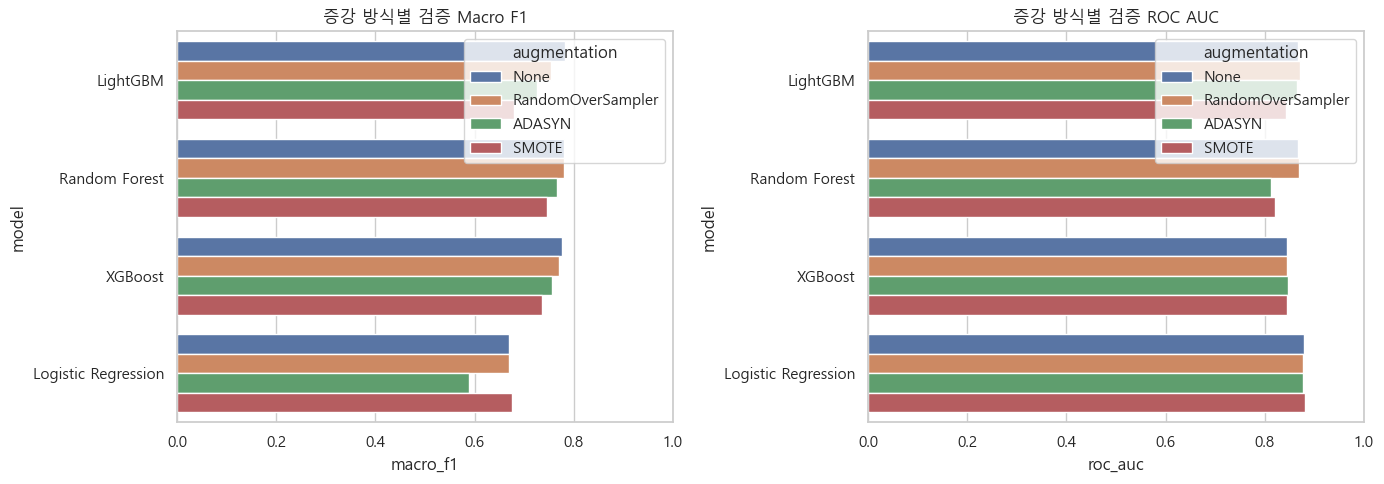

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=summary_df, x='macro_f1', y='model', hue='augmentation', ax=axes[0])
axes[0].set_title('증강 방식별 검증 Macro F1')
axes[0].set_xlim(0, 1)
sns.barplot(data=summary_df, x='roc_auc', y='model', hue='augmentation', ax=axes[1])
axes[1].set_title('증강 방식별 검증 ROC AUC')
axes[1].set_xlim(0, 1)
plt.tight_layout()

## 증강 방식별 비용-편익 분석

최고 성능 조합 하나만 고르지 않고, 모든 모델과 증강 방식 조합에 대해 validation 기준 비용을 계산한다. FP 비용은 건당 고정 비용만 사용한다.

In [20]:
# 모든 조합의 validation 예측 결과를 비용 관점에서 비교한다.
COST_FIXED_FP = 23.0


def recovery_cost_per_1000(delay_days):
    # FN은 실제 연체를 놓친 경우로 보고, 연체 기간별 회수 비용을 적용한다.
    if delay_days <= 30:
        return 1.5
    if delay_days <= 60:
        return 5.0
    if delay_days <= 90:
        return 8.0
    return 10.5


def make_cost_summary(row):
    frame = valid_raw.copy().reset_index(drop=True)
    frame['y_true'] = y_valid.reset_index(drop=True).values
    frame['y_pred'] = np.asarray(row['valid_pred']).astype(int)
    frame['pred_proba'] = np.asarray(row['valid_proba'])
    frame['delay_days'] = frame['business_days_late'].clip(lower=0)
    frame['amount_usd_actual'] = np.expm1(frame['amount_in_usd'])

    frame['is_fn'] = (frame['y_true'] == 1) & (frame['y_pred'] == 0)
    frame['is_fp'] = (frame['y_true'] == 0) & (frame['y_pred'] == 1)
    frame['is_tp'] = (frame['y_true'] == 1) & (frame['y_pred'] == 1)
    frame['is_tn'] = (frame['y_true'] == 0) & (frame['y_pred'] == 0)

    frame['cost_per_1000'] = frame['delay_days'].apply(recovery_cost_per_1000)
    frame['fn_recovery_cost'] = np.where(
        frame['is_fn'],
        frame['amount_usd_actual'] / 1000 * frame['cost_per_1000'],
        0.0,
    )
    frame['fp_fixed_cost'] = np.where(frame['is_fp'], COST_FIXED_FP, 0.0)
    frame['total_error_cost'] = frame['fn_recovery_cost'] + frame['fp_fixed_cost']

    return {
        'model': row['model'],
        'augmentation': row['augmentation'],
        'accuracy': row['accuracy'],
        'macro_f1': row['macro_f1'],
        'roc_auc': row['roc_auc'],
        'tp': int(frame['is_tp'].sum()),
        'tn': int(frame['is_tn'].sum()),
        'fp': int(frame['is_fp'].sum()),
        'fn': int(frame['is_fn'].sum()),
        'fn_recovery_cost': frame['fn_recovery_cost'].sum(),
        'fp_fixed_cost': frame['fp_fixed_cost'].sum(),
        'total_error_cost': frame['total_error_cost'].sum(),
    }


cost_summary_df = pd.DataFrame([make_cost_summary(row) for row in results])
cost_summary_df = cost_summary_df.sort_values('total_error_cost').reset_index(drop=True)
display(cost_summary_df)

,model,augmentation,accuracy,macro_f1,roc_auc,tp,tn,fp,fn,fn_recovery_cost,fp_fixed_cost,total_error_cost
0,Random Forest,RandomOverSampler,0.959219,0.780481,0.869660,182,5957,49,212,10240.210989,1127.0,11367.210989
1,Random Forest,None,0.960625,0.780368,0.867142,175,5973,33,219,10632.011570,759.0,11391.011570
2,XGBoost,None,0.957500,0.776316,0.845721,184,5944,62,210,9995.949819,1426.0,11421.949819
3,LightGBM,None,0.958750,0.782895,0.867386,188,5948,58,206,10298.110194,1334.0,11632.110194
4,XGBoost,RandomOverSampler,0.950781,0.770311,0.845811,206,5879,127,188,9506.537210,2921.0,12427.537210
5,Random Forest,ADASYN,0.949375,0.765265,0.812717,204,5872,134,190,9773.397475,3082.0,12855.397475
6,XGBoost,ADASYN,0.945312,0.756403,0.846950,207,5843,163,187,9401.206089,3749.0,13150.206089
7,LightGBM,RandomOverSampler,0.941719,0.755044,0.871292,220,5807,199,174,8972.455891,4577.0,13549.455891
8,Random Forest,SMOTE,0.941250,0.745770,0.821101,206,5818,188,188,9789.717081,4324.0,14113.717081
9,XGBoost,SMOTE,0.932031,0.735429,0.844122,224,5741,265,170,8367.459739,6095.0,14462.459739


비용 기준 최저 조합
model: Random Forest
augmentation: RandomOverSampler
total_error_cost: $11,367
macro_f1: 0.7805


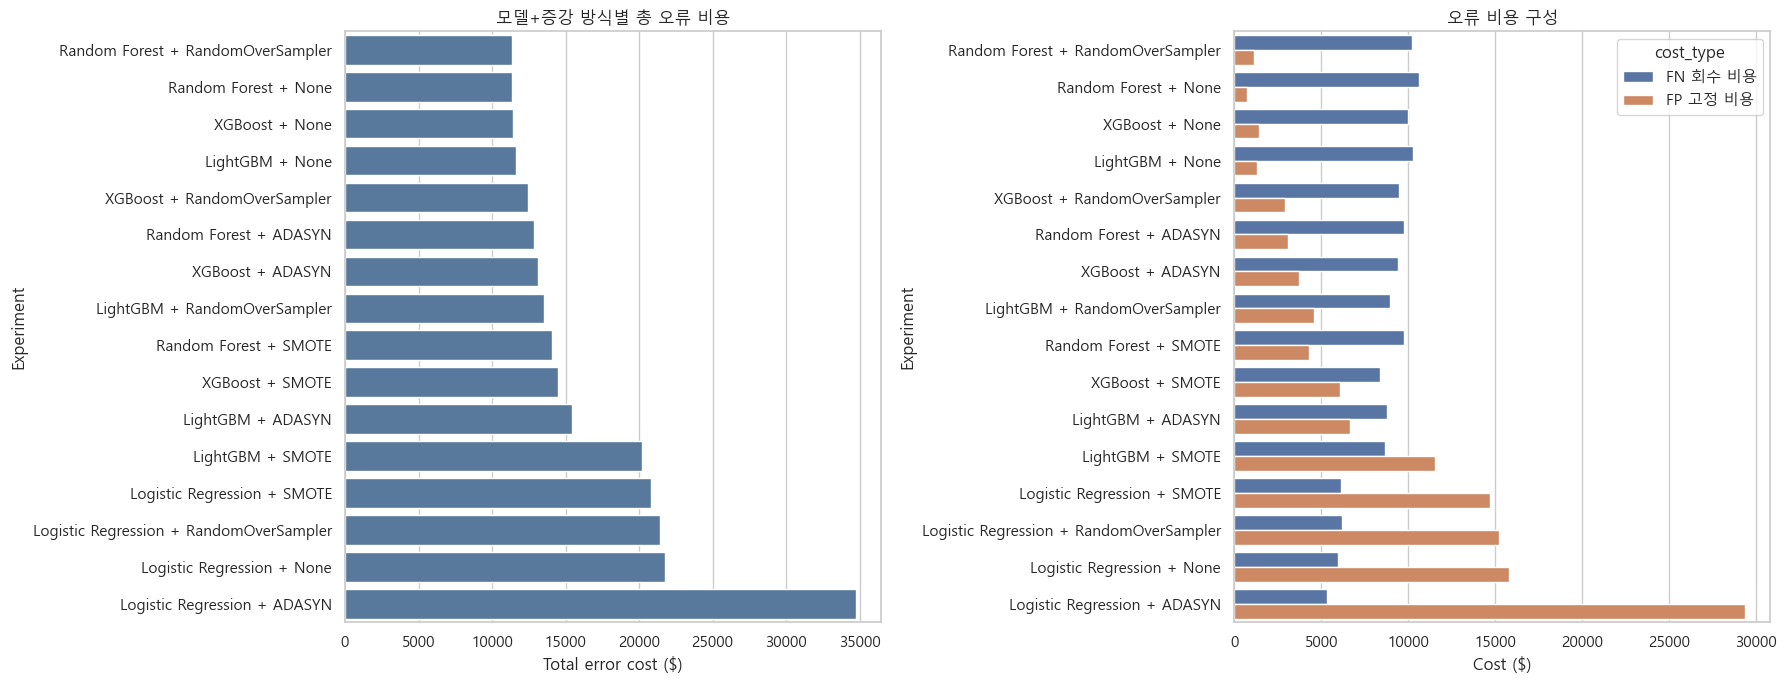

In [21]:
# 비용 기준으로 모델+증강 방식 조합을 비교한다.
cost_plot_df = cost_summary_df.melt(
    id_vars=['model', 'augmentation'],
    value_vars=['fn_recovery_cost', 'fp_fixed_cost'],
    var_name='cost_type',
    value_name='cost',
)
cost_plot_df['cost_type'] = cost_plot_df['cost_type'].map({
    'fn_recovery_cost': 'FN 회수 비용',
    'fp_fixed_cost': 'FP 고정 비용',
})
cost_plot_df['experiment'] = cost_plot_df['model'] + ' + ' + cost_plot_df['augmentation']
cost_summary_df['experiment'] = cost_summary_df['model'] + ' + ' + cost_summary_df['augmentation']

ordered_experiments = cost_summary_df.sort_values('total_error_cost')['experiment'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=cost_summary_df,
    x='total_error_cost',
    y='experiment',
    order=ordered_experiments,
    ax=axes[0],
    color='#4C78A8',
)
axes[0].set_title('모델+증강 방식별 총 오류 비용')
axes[0].set_xlabel('Total error cost ($)')
axes[0].set_ylabel('Experiment')

sns.barplot(
    data=cost_plot_df,
    x='cost',
    y='experiment',
    hue='cost_type',
    order=ordered_experiments,
    ax=axes[1],
)
axes[1].set_title('오류 비용 구성')
axes[1].set_xlabel('Cost ($)')
axes[1].set_ylabel('Experiment')

plt.tight_layout()

best_cost_row = cost_summary_df.iloc[0]
print('비용 기준 최저 조합')
print(f"model: {best_cost_row['model']}")
print(f"augmentation: {best_cost_row['augmentation']}")
print(f"total_error_cost: ${best_cost_row['total_error_cost']:,.0f}")
print(f"macro_f1: {best_cost_row['macro_f1']:.4f}")

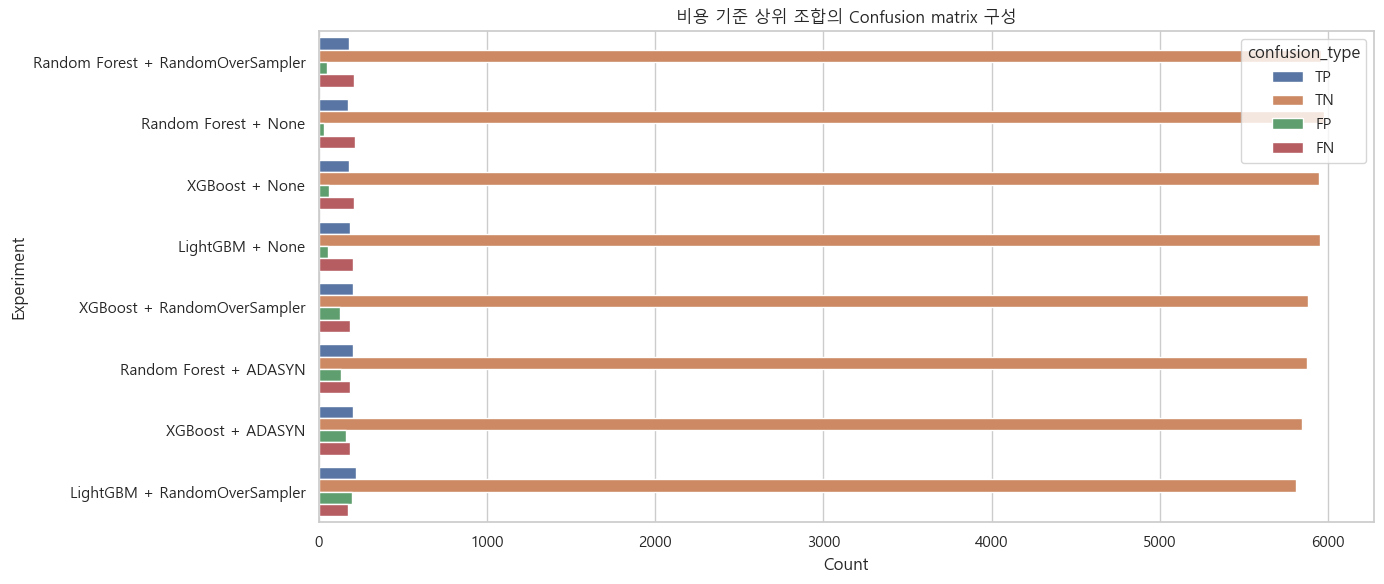

In [22]:
# 비용 기준 상위 조합들의 confusion matrix 구성을 비교한다.
top_n = 8
top_cost_df = cost_summary_df.head(top_n).copy()
confusion_plot_df = top_cost_df.melt(
    id_vars=['experiment'],
    value_vars=['tp', 'tn', 'fp', 'fn'],
    var_name='confusion_type',
    value_name='count',
)
confusion_plot_df['confusion_type'] = confusion_plot_df['confusion_type'].str.upper()

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=confusion_plot_df,
    x='count',
    y='experiment',
    hue='confusion_type',
    order=top_cost_df['experiment'].tolist(),
    ax=ax,
)
ax.set_title('비용 기준 상위 조합의 Confusion matrix 구성')
ax.set_xlabel('Count')
ax.set_ylabel('Experiment')
plt.tight_layout()